# Práctica: cv2 (OpenCV) en Python

**Materia:** Recuperación de la Información

Este notebook explica y demuestra el uso de la librería **cv2** (el módulo de Python de OpenCV) para procesamiento de imágenes, con ejemplos ejecutables.

## ¿Para qué sirve?

`cv2` es el binding de Python para **OpenCV** (Open Source Computer Vision Library), una librería de visión por computadora y procesamiento de imágenes de código abierto. Sirve para leer, transformar, analizar y extraer información de imágenes y video: detectar bordes, formas, rostros, objetos, colores, texto, movimiento, entre otros usos, lo cual la conecta directamente con la recuperación de información visual (buscar y extraer características relevantes de imágenes).

## ¿Cómo funciona?

OpenCV representa las imágenes como **arreglos de NumPy** (matrices de píxeles). Cada operación (difuminar, detectar bordes, cambiar de color, etc.) es una transformación matemática aplicada a esa matriz:

1. Se **carga o genera** una imagen como matriz de píxeles (alto x ancho x canales de color, en formato BGR por defecto, no RGB).
2. Se aplican **filtros y transformaciones** (conversión de color, desenfoque, umbralización, detección de bordes, etc.) mediante funciones de la librería.
3. El resultado es una **nueva matriz** que se puede mostrar, guardar o seguir procesando.
4. Para detección de estructuras (contornos, rostros, etc.) OpenCV utiliza algoritmos clásicos de visión por computadora (gradientes, clasificadores en cascada, etc.) sobre esa matriz.

## ¿Qué tipo de operaciones se pueden realizar?

- **Lectura/escritura** de imágenes y video (`cv2.imread`, `cv2.imwrite`, `cv2.VideoCapture`).
- **Conversión de espacio de color** (BGR a escala de grises, HSV, etc.) con `cv2.cvtColor`.
- **Filtrado y desenfoque** (`cv2.GaussianBlur`, `cv2.medianBlur`).
- **Detección de bordes** (`cv2.Canny`).
- **Umbralización / binarización** (`cv2.threshold`).
- **Detección de contornos y formas** (`cv2.findContours`).
- **Dibujo** de figuras y texto sobre imágenes (`cv2.rectangle`, `cv2.circle`, `cv2.putText`).
- **Detección de rostros** con clasificadores en cascada (`cv2.CascadeClassifier`).
- **Transformaciones geométricas** (rotar, escalar, recortar).

## Ejemplo simple: creación y procesamiento de una imagen

Como no tenemos una cámara ni una imagen externa disponible, generamos una imagen sintética con formas geométricas para poder demostrar cada operación de forma reproducible.

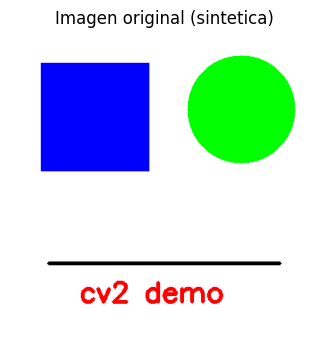

Dimensiones de la imagen: (400, 400, 3)


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Crear una imagen sintetica de 400x400 con fondo blanco
img = np.full((400, 400, 3), 255, dtype=np.uint8)

# Dibujar algunas formas
cv2.rectangle(img, (40, 40), (180, 180), (255, 0, 0), thickness=-1)   # rectangulo azul (BGR)
cv2.circle(img, (300, 100), 70, (0, 255, 0), thickness=-1)             # circulo verde
cv2.line(img, (50, 300), (350, 300), (0, 0, 0), thickness=3)           # linea negra
cv2.putText(img, 'cv2 demo', (90, 350), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3)

plt.figure(figsize=(4,4))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen original (sintetica)')
plt.axis('off')
plt.show()
print('Dimensiones de la imagen:', img.shape)

### Conversión a escala de grises

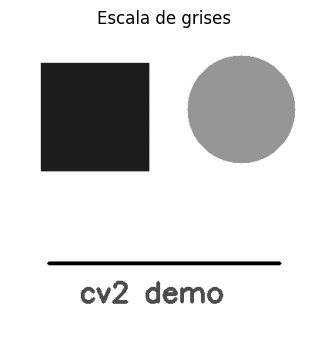

Forma: (400, 400) (un solo canal)


In [2]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(4,4))
plt.imshow(gray, cmap='gray')
plt.title('Escala de grises')
plt.axis('off')
plt.show()
print('Forma:', gray.shape, '(un solo canal)')

### Desenfoque (Gaussian Blur)

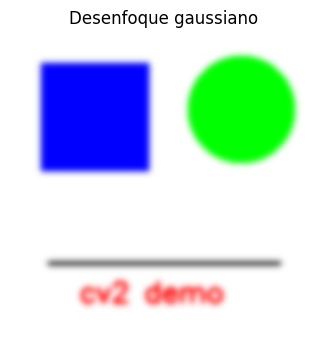

In [3]:
blurred = cv2.GaussianBlur(img, (25, 25), 0)
plt.figure(figsize=(4,4))
plt.imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB))
plt.title('Desenfoque gaussiano')
plt.axis('off')
plt.show()

### Detección de bordes (Canny)

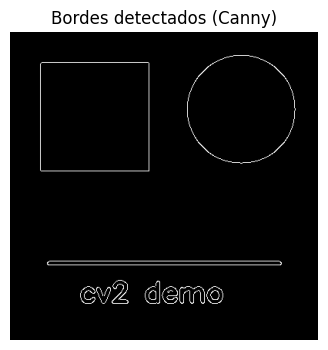

In [4]:
edges = cv2.Canny(gray, 50, 150)
plt.figure(figsize=(4,4))
plt.imshow(edges, cmap='gray')
plt.title('Bordes detectados (Canny)')
plt.axis('off')
plt.show()

### Detección y conteo de contornos

A partir de los bordes/umbral, `cv2.findContours` identifica las siluetas de las figuras dibujadas y permite contarlas o medirlas.

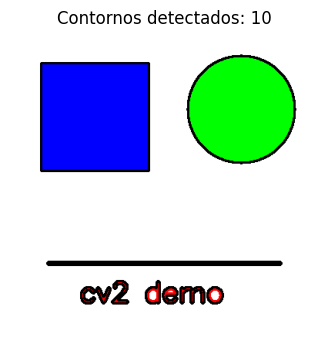

Contorno 0: area=327.0px, bounding box=(256,331,21,22)
Contorno 1: area=304.0px, bounding box=(221,331,32,22)
Contorno 2: area=256.0px, bounding box=(198,331,20,22)
Contorno 3: area=156.5px, bounding box=(112,331,19,22)
Contorno 4: area=178.5px, bounding box=(92,331,19,22)
Contorno 5: area=365.0px, bounding box=(176,323,19,30)
Contorno 6: area=250.5px, bounding box=(132,323,22,30)
Contorno 7: area=1208.0px, bounding box=(48,298,305,5)
Contorno 8: area=19600.0px, bounding box=(40,40,141,141)
Contorno 9: area=15176.0px, bounding box=(230,30,141,141)


In [5]:
_, thresh = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_contornos = img.copy()
cv2.drawContours(img_contornos, contours, -1, (0, 0, 0), 2)

plt.figure(figsize=(4,4))
plt.imshow(cv2.cvtColor(img_contornos, cv2.COLOR_BGR2RGB))
plt.title(f'Contornos detectados: {len(contours)}')
plt.axis('off')
plt.show()

for i, c in enumerate(contours):
    area = cv2.contourArea(c)
    x, y, w, h = cv2.boundingRect(c)
    print(f'Contorno {i}: area={area:.1f}px, bounding box=({x},{y},{w},{h})')

## Conclusión

Con un puñado de funciones (`cvtColor`, `GaussianBlur`, `Canny`, `findContours`) fue posible pasar de una imagen a información estructurada (número de figuras, tamaño y posición de cada una), que es la idea central de usar visión por computadora dentro de tareas de recuperación de información visual.